전처리 과정 생략
자치구 별 단계 구분도 시각화

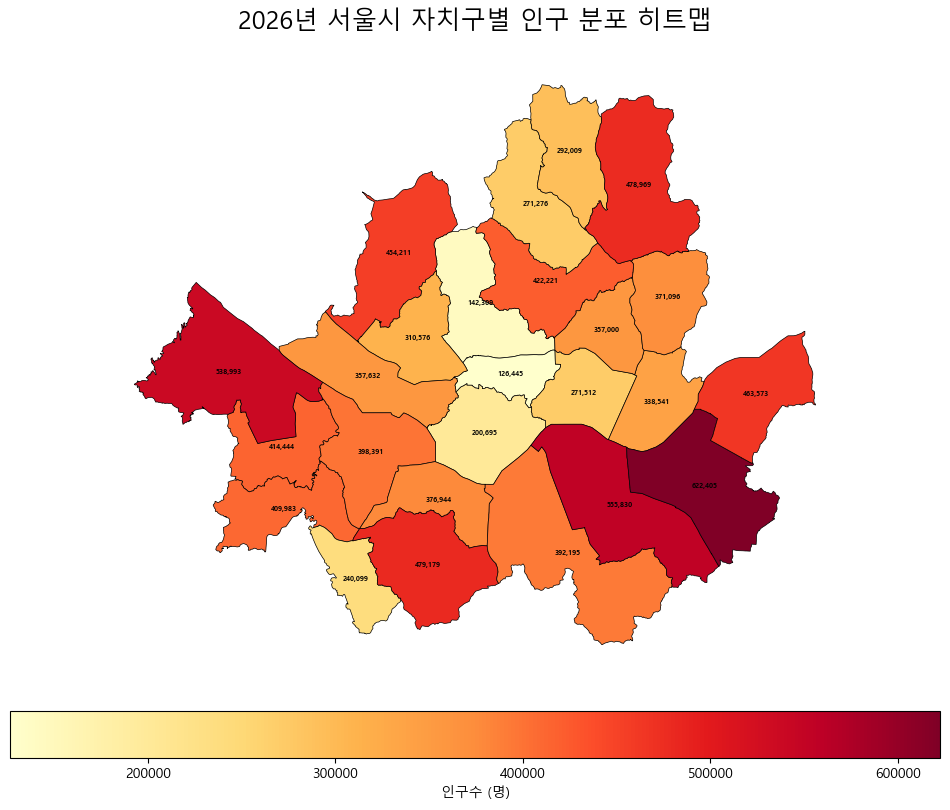

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from plt_style import set_korean

set_korean()

# --- 1. 데이터 로드 및 전처리 ---
# CSV 파일 읽기 (헤더가 복잡하므로 header=None으로 읽은 뒤 필요한 행/열만 추출)
df = pd.read_csv('data/자치구별+총인구(추계인구).csv', header=None)

# 데이터 추출 규칙:
# - 행: 인덱스 4번부터 실제 자치구 데이터 시작 (3번 '합계' 행 제외)
# - 열: 인덱스 1번(자치구명), 인덱스 2번(총인구 소계)
pop_df = df.iloc[4:, [1, 2]].copy()
pop_df.columns = ['자치구', '인구수']

# '인구수' 컬럼을 숫자로 변환
pop_df['인구수'] = pd.to_numeric(pop_df['인구수'])

# --- 2. 지리 정보(GeoJSON) 로드 ---
# 사용자가 지정한 경로의 파일 로드
gdf = gpd.read_file('polygon/서울시_자치구.geojson')
merge_col = 'SIG_KOR_NM' 

# --- 3. 데이터 병합 (Join) ---
merged = gdf.merge(pop_df, left_on=merge_col, right_on='자치구')

# --- 4. 정적 단계 구분도(Choropleth Map) 시각화 ---
# 한글 깨짐 방지 설정 (로컬 환경의 폰트에 맞춰 설정하세요)
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 기준
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1) 지도 그리기
merged.plot(column='인구수', 
            cmap='YlOrRd',       # 노랑-주황-빨강 색상 조합
            legend=True, 
            edgecolor='black',    # 구 경계선 색상
            linewidth=0.5,        # 경계선 두께
            ax=ax,
            legend_kwds={'label': "인구수 (명)", 'orientation': "horizontal", 'pad': 0.05})

# 2) 각 자치구 위에 숫자(인구수) 추가하기
for idx, row in merged.iterrows():
    # 폴리곤의 중심점 구하기
    centroid = row.geometry.centroid
    
    # 숫자 포맷팅 (예: 142,309명 -> 천단위 콤마 추가)
    label = f"{int(row['인구수']):,}"
    
    # 텍스트 출력 (중심점 x, y 좌표 사용)
    ax.text(centroid.x, centroid.y, label, 
            fontsize=5, 
            ha='center',      # 가로 정렬: 중앙
            va='center',      # 세로 정렬: 중앙
            fontweight='bold', 
            color='black')    # 배경색에 따라 'white'로 변경 가능

# 제목 및 축 설정
plt.title('2026년 서울시 자치구별 인구 분포 히트맵', fontsize=18, pad=20)
ax.axis('off') # 위도/경도 축 숨기기
plt.show()

신고 증감률 (2021 vs 2024)


📊 2021년 대비 2024년 자치구별 사고 증감률 (상위 5개)
   SIG_KOR_NM  count_2021  count_2024        증감률
0         강남구       42355       48999  15.686460
22        종로구       20117       23074  14.699011
11        동작구       21799       24971  14.551126
12        마포구       28561       32705  14.509296
23         중구       19199       21665  12.844419


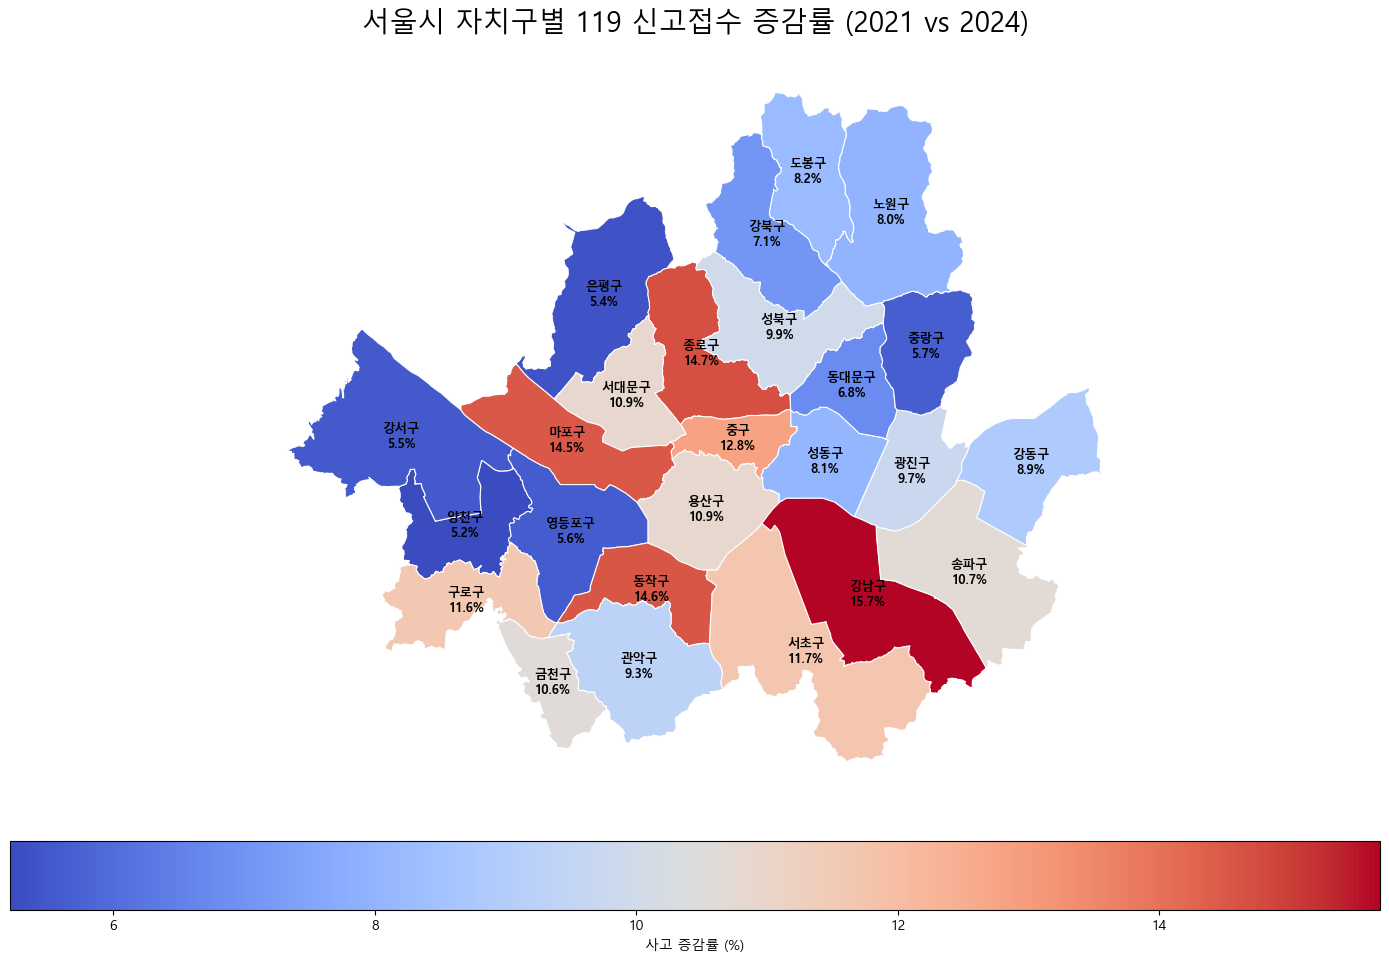

In [4]:
# 1. 환경 설정
years = [2021, 2024]
dfs = []

# 2. 데이터 로드 및 연도별 집계 (파일 생성 없이 메모리에서 처리)
# '자치구' 정보를 추출하기 위해 자치구 GeoJSON을 먼저 로드합니다.
gu_gdf = gpd.read_file('polygon/서울시_자치구.geojson').to_crs("EPSG:4326")
gu_name_col = 'SIG_KOR_NM'  # GeoJSON의 자치구 이름 컬럼

for year in years:
    # 데이터 로드
    file_path = f'119 신고접수 현황/신고접수_{year}.csv'
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.upper()
    
    # 좌표 데이터 클리닝
    df_clean = df.dropna(subset=['DAMG_RGN_LOT', 'DAMG_RGN_LAT']).copy()
    
    # GeoDataFrame 변환
    gdf = gpd.GeoDataFrame(
        df_clean, 
        geometry=gpd.points_from_xy(df_clean['DAMG_RGN_LOT'], df_clean['DAMG_RGN_LAT']),
        crs="EPSG:4326")
    
    # 공간 결합 (어느 자치구에 속하는지 판별)
    joined = gpd.sjoin(gdf, gu_gdf[[gu_name_col, 'geometry']], predicate='within', how='inner')
    
    # 자치구별 사고 건수 집계
    counts = joined.groupby(gu_name_col).size().reset_index(name=f'count_{year}')
    dfs.append(counts)

# 3. 증감률 계산 (2021년 vs 2024년)
# 두 연도의 데이터를 하나로 합침
comparison_df = pd.merge(dfs[0], dfs[1], on=gu_name_col)

# 증감률 공식: ((현재 - 과거) / 과거) * 100
comparison_df['증감률'] = ((comparison_df['count_2024'] - comparison_df['count_2021']) / comparison_df['count_2021']) * 100

# 결과 출력 (맛보기)
print("\n" + "="*50)
print("📊 2021년 대비 2024년 자치구별 사고 증감률 (상위 5개)")
print(comparison_df.sort_values(by='증감률', ascending=False).head())
print("="*50)

# 4. 시각화 (지도에 반영)
# GeoJSON 데이터와 증감률 데이터 병합
final_gdf = gu_gdf.merge(comparison_df, on=gu_name_col)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# 단계 구분도 그리기 (증감률 기준)
# RdYlGn (Red-Yellow-Green)은 증가 시 빨강, 감소 시 초록으로 표현하기 좋음 (반전 가능)
final_gdf.plot(column='증감률', 
               cmap='coolwarm',     # 증가(빨강), 감소(파랑) 직관적 대비
               legend=True, 
               edgecolor='white', 
               linewidth=0.8, 
               ax=ax,
               legend_kwds={'label': "사고 증감률 (%)", 'orientation': "horizontal", 'pad': 0.05})

# 자치구명과 증감률 수치 텍스트 추가
for idx, row in final_gdf.iterrows():
    centroid = row.geometry.centroid
    ann_text = f"{row[gu_name_col]}\n{row['증감률']:.1f}%"
    ax.text(centroid.x, centroid.y, ann_text, fontsize=9, ha='center', va='center', fontweight='bold')

plt.title('서울시 자치구별 119 신고접수 증감률 (2021 vs 2024)', fontsize=20, pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()

+ 2021 ~~ 2024 신고 현황도

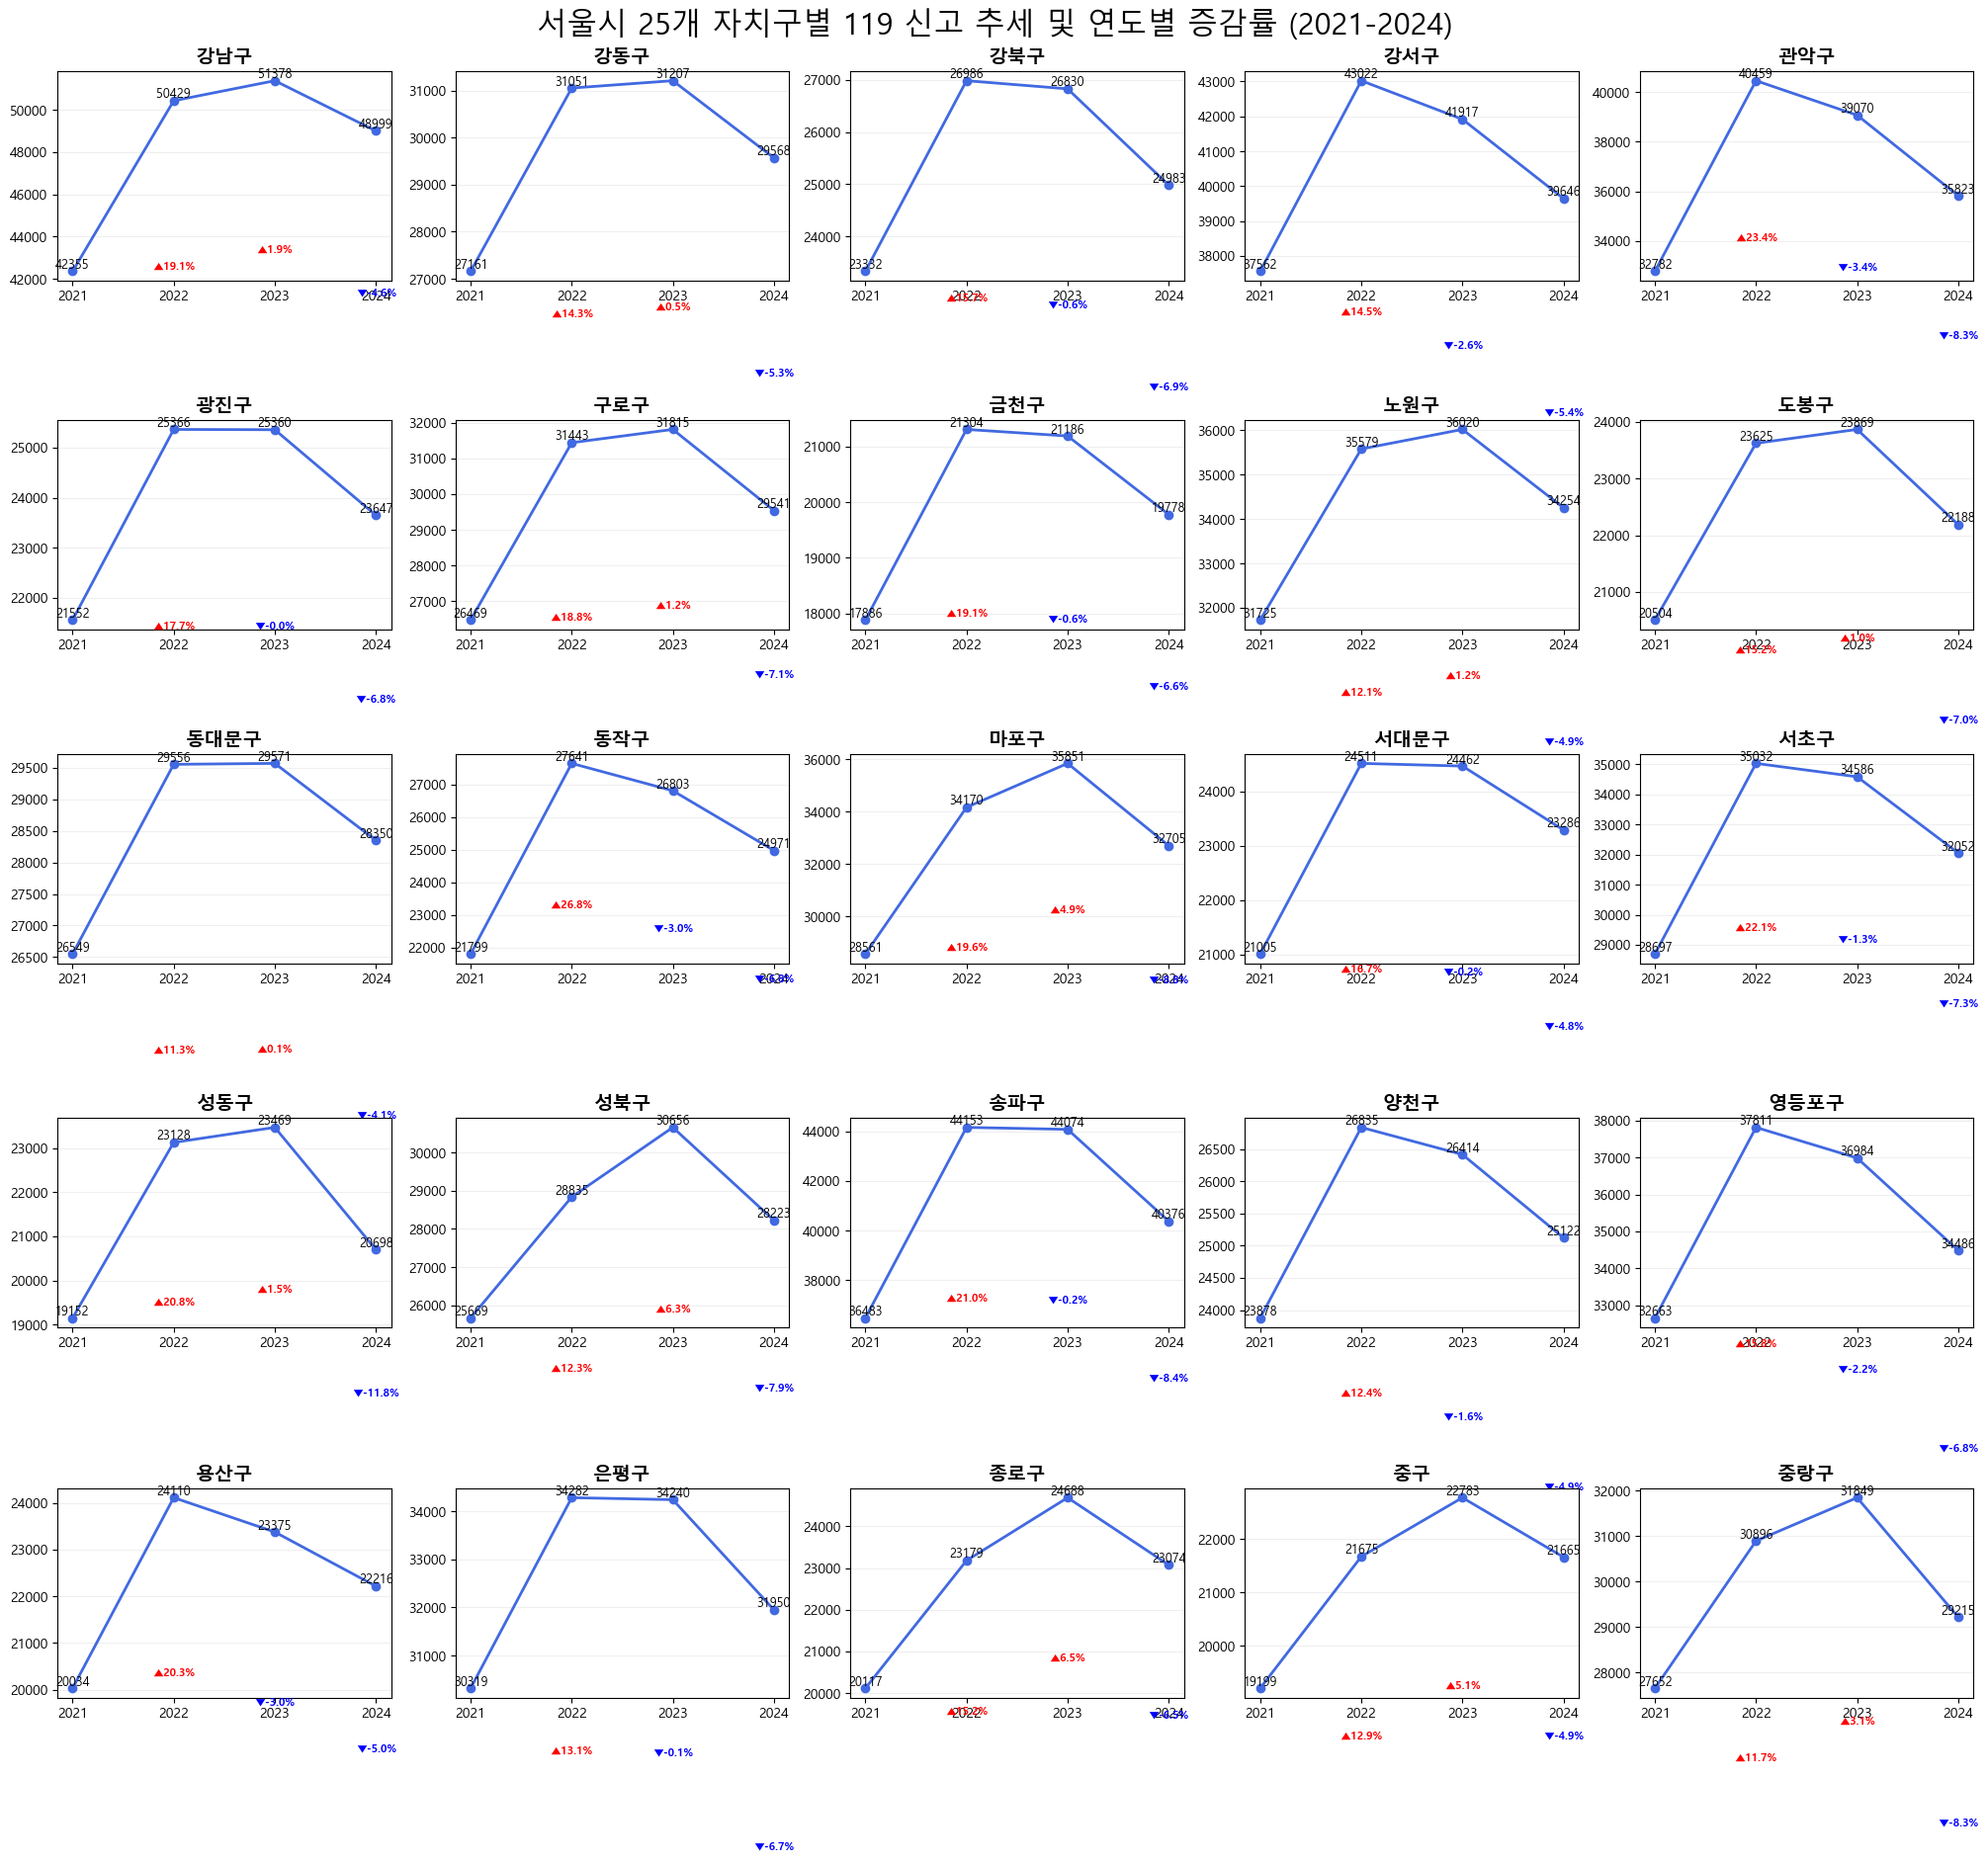

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from plt_style import set_korean 

set_korean()

# --- 1. 데이터 수집 및 통합 (2021-2024) ---
all_years_data = []
gu_gdf = gpd.read_file('polygon/서울시_자치구.geojson').to_crs("EPSG:4326")
gu_name_col = 'SIG_KOR_NM'

for year in [2021, 2022, 2023, 2024]:
    df = pd.read_csv(f'119 신고접수 현황/신고접수_{year}.csv', encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.upper()
    df_clean = df.dropna(subset=['DAMG_RGN_LOT', 'DAMG_RGN_LAT']).copy()
    
    gdf = gpd.GeoDataFrame(df_clean, 
                           geometry=gpd.points_from_xy(df_clean['DAMG_RGN_LOT'], df_clean['DAMG_RGN_LAT']),
                           crs="EPSG:4326")
    
    joined = gpd.sjoin(gdf, gu_gdf[[gu_name_col, 'geometry']], predicate='within', how='inner')
    counts = joined.groupby(gu_name_col).size().reset_index(name='사고건수')
    counts['연도'] = year
    all_years_data.append(counts)

df_trend = pd.concat(all_years_data)

# --- 2. 5x5 그리드 시각화 (전체 자치구) ---
fig, axes = plt.subplots(5, 5, figsize=(20, 18), constrained_layout=True)
axes = axes.flatten()

# 모든 자치구 리스트 (이름순 정렬)
all_gu = sorted(df_trend[gu_name_col].unique())

for i, gu in enumerate(all_gu):
    ax = axes[i]
    data = df_trend[df_trend[gu_name_col] == gu].sort_values('연도')
    
    # 선 그래프 그리기
    line = ax.plot(data['연도'], data['사고건수'], marker='o', color='royalblue', linewidth=2)
    ax.set_title(gu, fontsize=14, fontweight='bold')
    ax.set_xticks([2021, 2022, 2023, 2024])
    ax.grid(True, axis='y', alpha=0.2)

    # --- 증감률 계산 및 표시 ---
    # shift()를 이용해 전년도 데이터를 가져와 계산
    data['prev_count'] = data['사고건수'].shift(1)
    data['change_rate'] = ((data['사고건수'] - data['prev_count']) / data['prev_count']) * 100

    for idx, row in data.iterrows():
        # 수치 표시 (사고 건수)
        ax.text(row['연도'], row['사고건수'], f"{int(row['사고건수'])}", 
                ha='center', va='bottom', fontsize=9)
        
        # 증감률 표시 (2022년부터)
        if not pd.isna(row['change_rate']):
            color = 'red' if row['change_rate'] > 0 else 'blue'
            symbol = '▲' if row['change_rate'] > 0 else '▼'
            ax.text(row['연도'], row['사고건수'] * 0.85, f"{symbol}{row['change_rate']:.1f}%", 
                    ha='center', va='top', fontsize=8, color=color, fontweight='bold')

# 남는 서브플롯(있다면) 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('서울시 25개 자치구별 119 신고 추세 및 연도별 증감률 (2021-2024)', fontsize=22, y=1.02)
plt.show()

자치구 단위 차원 통합 및 RBI 산출 파트

In [ ]:
# --- 1. 안전센터 데이터 로드 및 처리 ---
df_center_raw = pd.read_csv('data/시내주요기관 수.csv', header=None)
center_df = df_center_raw.iloc[3:, [1, 2]].copy()
center_df.columns = ['자치구', '안전센터수']
center_df = center_df[center_df['자치구'] != '기타']
center_df['안전센터수'] = center_df['안전센터수'].astype(int)

# --- 2. 출동건수 데이터 로드 및 처리 ---
df_dispatch_raw = pd.read_csv('data/119 구조활동 실적(구별).csv', header=None)
dispatch_df = df_dispatch_raw.iloc[5:, [1, 2]].copy()
dispatch_df.columns = ['자치구', '출동건수']
dispatch_df = dispatch_df[dispatch_df['자치구'] != '기타']
dispatch_df['출동건수'] = pd.to_numeric(dispatch_df['출동건수'], errors='coerce')
dispatch_df = dispatch_df.dropna(subset=['출동건수'])
dispatch_df['출동건수'] = dispatch_df['출동건수'].astype(int)

# --- 3. 화재사고 데이터 집계 ---
df_fire_raw = pd.read_csv('data/화재사고 구조출동 현황/화재사고_2024.csv', encoding='utf-8-sig')
fire_counts = df_fire_raw['GRNDS_SGG_NM'].value_counts().reset_index()
fire_counts.columns = ['자치구', '화재사고건수']

# --- 4. 교통사고 데이터 집계 ---
df_traffic_raw = pd.read_csv('data/교통사고 구조출동 현황/교통사고_2024.csv', encoding='utf-8-sig')
traffic_counts = df_traffic_raw['GRNDS_SGG_NM'].value_counts().reset_index()
traffic_counts.columns = ['자치구', '교통사고건수']

# --- 5. 통합 데이터셋(risk_data) 구축 (모든 원천 컬럼 보존) ---
# 1) 인구 데이터 기반 시작
risk_data = pop_df.copy() # 자치구, 인구수 포함

# 2) 순차적 병합 (how='left'를 권장합니다. 혹시라도 데이터가 누락된 구가 있으면 NaN으로 파악하기 위함)
risk_data = pd.merge(risk_data, center_df, on='자치구', how='left')      # + 안전센터수
risk_data = pd.merge(risk_data, dispatch_df, on='자치구', how='left')    # + 출동건수
risk_data = pd.merge(risk_data, fire_counts, on='자치구', how='left')    # + 화재사고건수
risk_data = pd.merge(risk_data, traffic_counts, on='자치구', how='left') # + 교통사고건수

# 3) 결측치 및 데이터 타입 정제
# 사고가 발생하지 않아 데이터가 없는 구는 0으로 채우고 정수형으로 변환
cols_to_fix = ['안전센터수', '출동건수', '화재사고건수', '교통사고건수']
risk_data[cols_to_fix] = risk_data[cols_to_fix].fillna(0).astype(int)

# --- 6. 지표(Index) 컬럼 추가 (원천 데이터는 그대로 유지됨) ---

# [지표 1] 공급-수요 비율 (센터 1곳당 부담량)
risk_data['센터당_인구'] = risk_data['인구수'] / risk_data['안전센터수']
risk_data['센터당_화재'] = risk_data['화재사고건수'] / risk_data['안전센터수']
risk_data['센터당_출동'] = risk_data['출동건수'] / risk_data['안전센터수']

# [지표 2] 인구 대비 발생률 (인구 10만 명당 건수)
risk_data['인구10만당_화재'] = (risk_data['화재사고건수'] / risk_data['인구수']) * 100000
risk_data['인구10만당_출동'] = (risk_data['출동건수'] / risk_data['인구수']) * 100000
risk_data['인구10만당_교통'] = (risk_data['교통사고건수'] / risk_data['인구수']) * 100000

# [지표 3] LQ (입지계수: 서울 전체 평균 대비 해당 구의 집중도)
total_pop = risk_data['인구수'].sum()
total_fire = risk_data['화재사고건수'].sum()
total_rescue = risk_data['출동건수'].sum()

risk_data['LQ_화재'] = (risk_data['화재사고건수'] / total_fire) / (risk_data['인구수'] / total_pop)
risk_data['LQ_구조'] = (risk_data['출동건수'] / total_rescue) / (risk_data['인구수'] / total_pop)

print("✅ 모든 원천 데이터 및 지표가 통합 완료")
print(risk_data.head())

✅ 모든 원천 데이터 및 지표가 통합되었습니다.
   자치구     인구수  안전센터수  출동건수  화재사고건수  교통사고건수         센터당_인구      센터당_화재  \
0  종로구  142309      6  6291    1639     219   23718.166667  273.166667   
1   중구  126445      5  4455    1319     149   25289.000000  263.800000   
2  용산구  200695      5  6849    1415     336   40139.000000  283.000000   
3  성동구  271512      4  4903    1454     285   67878.000000  363.500000   
4  광진구  338541      3  6983    1815     267  112847.000000  605.000000   

        센터당_출동    인구10만당_화재    인구10만당_출동   인구10만당_교통     LQ_화재     LQ_구조  
0  1048.500000  1151.719146  4420.662080  153.890478  1.863907  1.933680  
1   891.000000  1043.141287  3523.270987  117.837795  1.688188  1.541144  
2  1369.800000   705.049951  3412.641072  167.418222  1.141031  1.492753  
3  1225.750000   535.519609  1805.813371  104.967736  0.866669  0.789896  
4  2327.666667   536.124133  2062.674831   78.867848  0.867647  0.902252  


In [18]:
risk_data.to_csv('output/자치구 단위 RBI.csv', index=False)